In [2]:
import pypsa
import os
import pandas as pd
import matplotlib.pyplot as plt

# CI Costs and Revenues

This notebook includes scripts to evaluate the cost analysis in different ways:
1) Total System Cost
2) CI Cost Balance
3) CI Cost by Country, Component or Carrier

## 1,2 - Total System Cost and CI Cost Balance

In [3]:
# 0 - Functions
def get_network_path(scenario, path = False):
    """
    Retrieve the network file path for a given scenario.
    
    - path = False means the default model repo path is used --> go back one level and go to "results/{scenario}/networks/network.nc"
    - path = "custom-path" means the networks are saved in a custom path where the network name is the same as the scenario name --> "custom-path/{scenario}.nc"
    """

    if not path: # Default model repo path: go back one level and go to results/...
        # Define the scenario directory
        scenario_dir = os.path.join("..", f"results/{scenario}/networks")
        if not os.path.exists(scenario_dir):
            print(f"Scenario directory {scenario_dir} not found, skipping.")
            return None
        
        # Get scenario network file
        nc_files = [f for f in os.listdir(scenario_dir) if f.endswith(".nc")]
        if not nc_files:
            print(f"Scenario network file not found in {scenario_dir}, skipping.")
            return None
        
        network_path = os.path.join(scenario_dir, nc_files[0])
        
    else: # If a custom path is provided, where the network name is the same as the scenario name
        # Define the scenario directory
        scenario_dir = path

        # Get scenario network file
        network_path = f"{scenario_dir}/{scenario}.nc"
        if not os.path.exists(network_path):
            print(f"{scenario} network file not found in {scenario_dir}, skipping.")
            return None

    return network_path



def extract_system_costs(n):
    opex = n.statistics.opex().sum()/1e9
    expanded_capex = n.statistics.expanded_capex().sum()/1e9
    installed_capex = n.statistics.installed_capex().sum()/1e9

    return pd.DataFrame({"Installed CAPEX":[installed_capex],"Expanded CAPEX":[expanded_capex],"OPEX":[opex]})

def get_ci_cost_balance(network,scenario):
    """Get CI costs and revenues from the network statistics, grouped by country, component, or carrier."""
    def get_ci(df):
        if "ci" in df.columns:
            return df.loc[~df.ci.isin(["","None"]), "ci"]
        return pd.Series(dtype=str)
    
    # Concatenate all ci values from generators, links, and storage_units
    all_ci = pd.concat([
        get_ci(network.generators),
        get_ci(network.links),
        get_ci(network.storage_units),
        get_ci(network.loads)
    ])
    
    # Get statistics as a DataFrame
    df = pd.DataFrame({
        "revenue": -network.statistics.revenue(nice_names=False, groupby=["name", "carrier", "country"]),
        "capex": network.statistics.capex(nice_names=False, groupby=["name", "carrier", "country"]),
        "opex": network.statistics.opex(nice_names=False, groupby=["name", "carrier", "country"]),
    }).fillna(0)/1e9 # EUR to BEUR
    
    # Filter rows where 'name' index level is in all_ci index, then map 'name' to corresponding ci
    df = df.loc[df.index.get_level_values("name").isin(all_ci.index)]
    
    # Create result with components grouped by metrics
    costs_CI = df.groupby(["component"]).sum()
    
    if "247-cfe" in scenario:
        unique_ci = pd.Series(network.loads.ci.unique())
        cleaned_ci = unique_ci[~unique_ci.isin(["", "None"])]
        
        import_ci = [i + " import" for i in cleaned_ci.to_list()]
        export_ci = [i + " export" for i in cleaned_ci.to_list()]
        
        e_import = -network.statistics.revenue(direction="input", nice_names=False, groupby=["name"],comps=["Link"]).groupby(["name"]).sum().loc[import_ci].sum()/1e9 # EUR to BEUR
        e_export = -network.statistics.revenue(direction="output", nice_names=False, groupby=["name"],comps=["Link"]).groupby(["name"]).sum().loc[export_ci].sum()/1e9 # EUR to BEUR
    
        df_result = pd.DataFrame(({"CAPEX":[costs_CI.loc[:,"capex"].sum()],
                         "OPEX":[costs_CI.loc[:,"opex"].sum()],
                         "Electricity Import":[e_import],
                         "Electricity Export":[e_export],
                        }))
                         
        df_result.index = [scenario]
    
    else:
        df_result = pd.DataFrame(({"CAPEX":[costs_CI.loc[:,"capex"].sum()],
                         "OPEX":[costs_CI.loc[:,"opex"].sum()],
                         "Electricity Import":[costs_CI.loc["Load","revenue"].sum()],
                         "Electricity Export":[costs_CI.loc[~costs_CI.index.isin(["Load"]),"revenue"].sum()],
                        }))
                         
        df_result.index = [scenario]
    
    return df_result

# Unused Extract Revenue from three methods
def extract_revenue(n):
    load_bus = n.loads_t['p'].T.groupby(n.loads['bus']).sum().T
    revenue = (load_bus * n.buses_t['marginal_price']).sum().sum()/1e9

    return pd.DataFrame({"Revenue":[revenue]})

def extract_revenue_stats(n):
    revenue = -n.statistics.revenue(comps=["Load"]).sum()/1e9

    return pd.DataFrame({"Revenue":[revenue]})

def extract_revenue_stats_gen(n):
    revenue = n.statistics.revenue(comps=["StorageUnit", "Generator", "Line", "Store", "Link"]).sum()/1e9

    return pd.DataFrame({"Revenue":[revenue]})

--------Planning Horizon: 2025--------


INFO:pypsa.io:Imported network baseline-2025-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: baseline-2025-1H----


INFO:pypsa.io:Imported network base_s_39___2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: vol-match-2025-ci25-1H----
Scenario directory ../results/vol-match-2025-country-ci25-1H/networks not found, skipping.


...

----Scenario: emi-match-2025-ci25-data-moer-1H----


INFO:pypsa.io:Imported network emi-match-2025-ci25-data-cmer-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: emi-match-2025-ci25-data-cmer-1H----
Scenario directory ../results/emi-match-2025-ci25-model-aer-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-mber-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-moer-3H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-cmer-1H/networks not found, skipping.
Scenario directory ../results/baseline-2025-NoResTargets-1H/networks not found, skipping.
Scenario directory ../results/vol-match-2025-NoResTargets-ci25-1H/networks not found, skipping.


,Installed CAPEX,Expanded CAPEX,OPEX
baseline-2025-1H,318.992387,42.467952,42.619459
vol-match-2025-ci25-1H,318.992266,44.677941,42.334222
247-cfe-2025-ci25-cfe100-1H,318.992272,219.985072,22.262807
247-cfe-2025-ci25-cfe90-1H,318.992272,103.542706,27.534793
emi-match-2025-ci25-data-aer-1H,318.992266,45.054212,42.011264
emi-match-2025-ci25-data-mber-1H,318.992266,46.924794,40.505722
emi-match-2025-ci25-data-moer-1H,318.992266,45.268208,41.730689
emi-match-2025-ci25-data-cmer-1H,318.992266,46.559749,40.616308


,CAPEX,OPEX,Electricity Import,Electricity Export
vol-match-2025-ci25-1H,21.015330,0.010937,2.438317e+01,-18.766132
247-cfe-2025-ci25-cfe100-1H,196.876171,0.085161,3.130570e-09,-14.501664
247-cfe-2025-ci25-cfe90-1H,77.342107,0.041538,2.217178e+00,-9.562042
emi-match-2025-ci25-data-aer-1H,21.015885,0.011020,2.429799e+01,-18.598521
emi-match-2025-ci25-data-mber-1H,22.164611,0.010941,2.390792e+01,-18.870576
emi-match-2025-ci25-data-moer-1H,21.058219,0.010917,2.422853e+01,-18.544370
emi-match-2025-ci25-data-cmer-1H,21.532607,0.010919,2.395558e+01,-18.684555


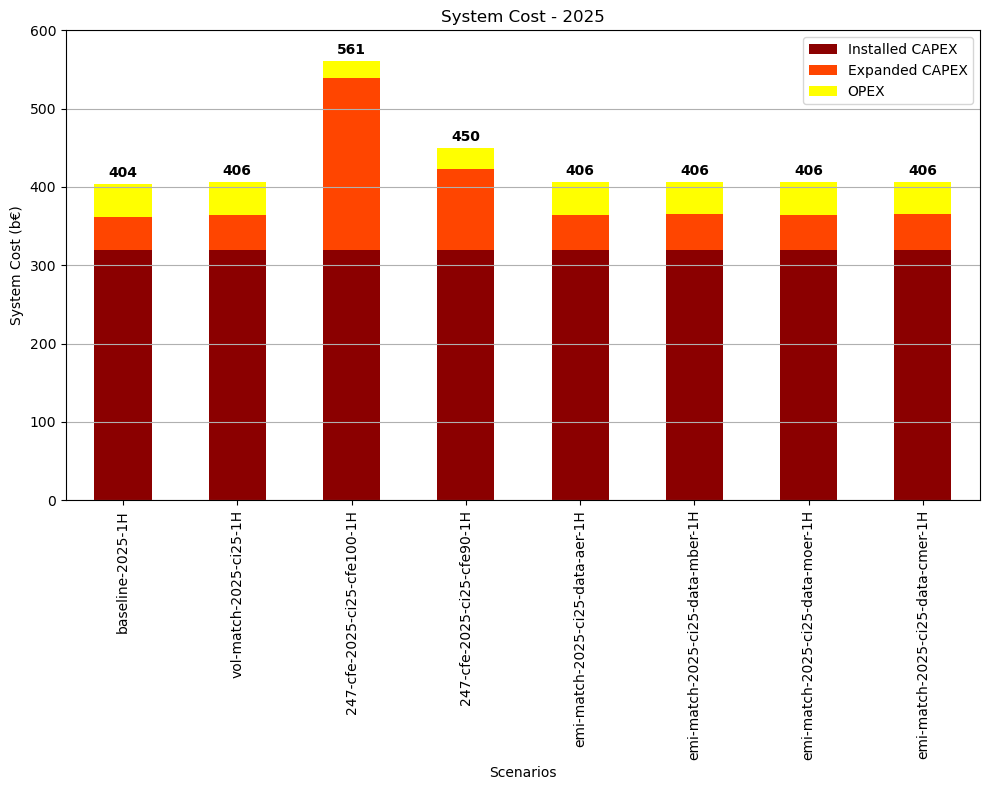

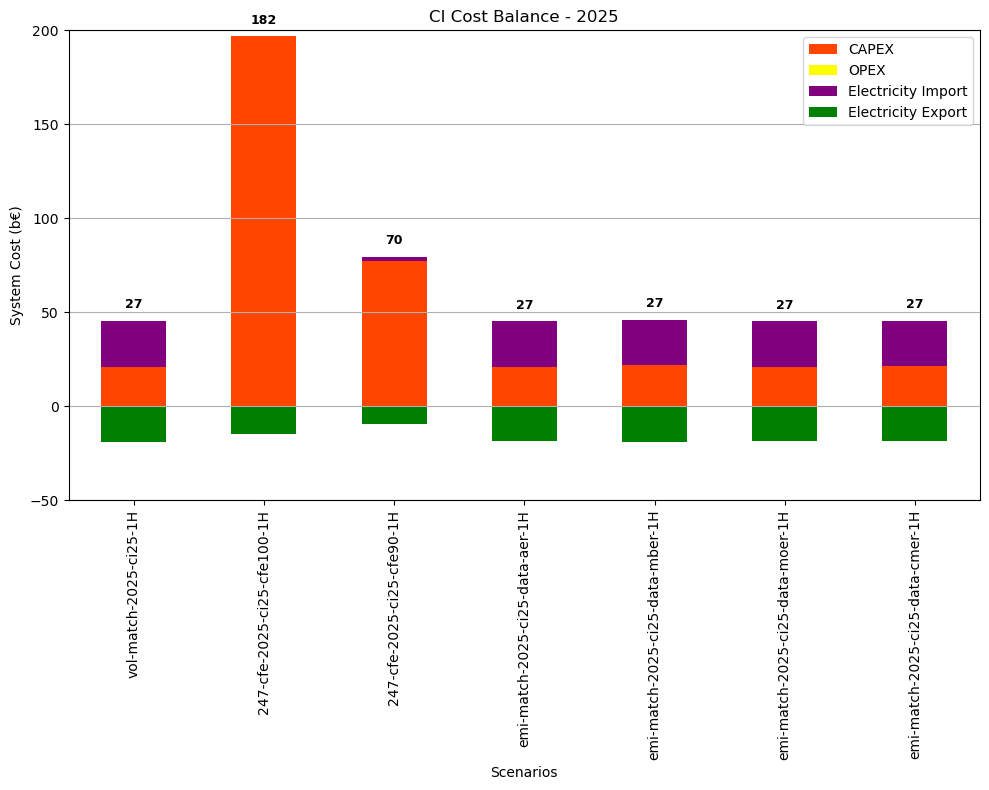

--------Planning Horizon: 2030--------


INFO:pypsa.io:Imported network baseline-2030-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: baseline-2030-1H----


INFO:pypsa.io:Imported network vol-match-2030-ci25-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: vol-match-2030-ci25-1H----


...

----Scenario: baseline-2030-NoResTargets-1H----


INFO:pypsa.io:Imported network vol-match-2030-NoResTargets-ci25-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: vol-match-2030-NoResTargets-ci25-1H----


,Installed CAPEX,Expanded CAPEX,OPEX
baseline-2030-1H,268.743281,70.740533,28.309855
vol-match-2030-ci25-1H,268.743160,71.817958,28.372676
vol-match-2030-country-ci25-1H,268.743160,72.475168,28.547796
247-cfe-2030-ci25-cfe100-1H,268.743014,205.395332,16.491301
247-cfe-2030-ci25-cfe90-1H,268.743014,117.133447,19.657301
emi-match-2030-ci25-model-aer-1H,268.743160,76.176229,26.117200
emi-match-2030-ci25-model-mber-1H,268.743160,77.417973,27.212786
emi-match-2030-ci25-model-moer-3H,268.743160,72.535500,28.194447
emi-match-2030-ci25-model-cmer-1H,268.743160,73.669274,28.348132
baseline-2030-NoResTargets-1H,268.743281,50.688792,38.398079


,CAPEX,OPEX,Electricity Import,Electricity Export
vol-match-2030-ci25-1H,16.984529,0.010537,1.975612e+01,-8.076921
vol-match-2030-country-ci25-1H,21.372477,0.010641,1.887440e+01,-11.545850
247-cfe-2030-ci25-cfe100-1H,166.369945,0.086531,8.560200e-10,-12.052630
247-cfe-2030-ci25-cfe90-1H,69.895360,0.044710,1.452919e+00,-7.675677
emi-match-2030-ci25-model-aer-1H,21.389482,0.011072,1.905516e+01,-13.243751
emi-match-2030-ci25-model-mber-1H,20.417515,0.010696,1.956794e+01,-9.868366
emi-match-2030-ci25-model-moer-3H,17.494821,0.010569,1.979239e+01,-9.904061
emi-match-2030-ci25-model-cmer-1H,20.279574,0.010832,1.963765e+01,-12.814301
vol-match-2030-NoResTargets-ci25-1H,18.035408,0.010508,2.371334e+01,-16.094573


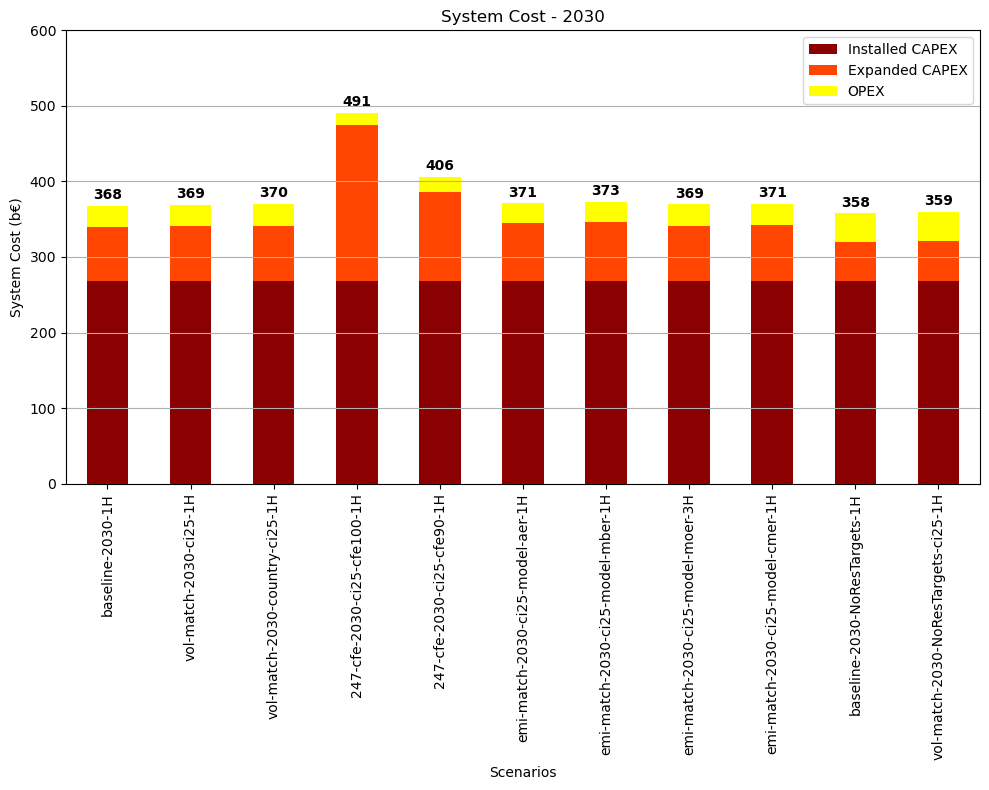

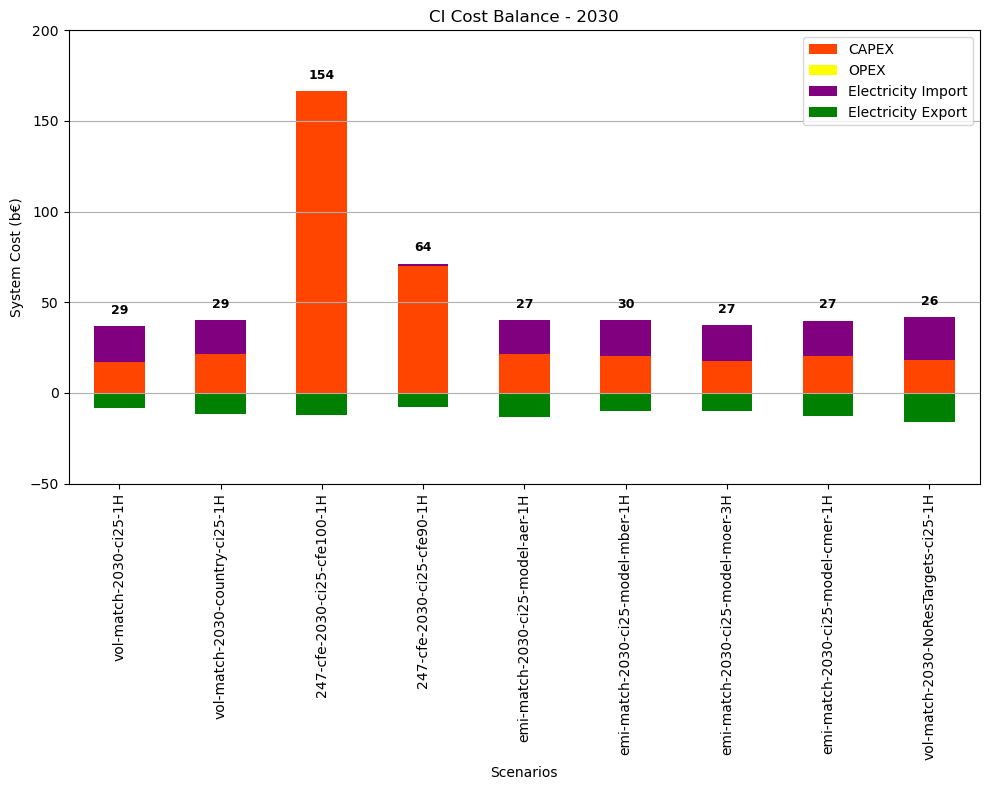

In [44]:
# 1 - Retrieve results
planning_horizon_list = ["2025", "2030"]
time_resolution = "1"
ci_participation = "25"

for planning_horizon in planning_horizon_list:
    print(f"--------Planning Horizon: {planning_horizon}--------")

    scenarios = [f"baseline-{planning_horizon}-{time_resolution}H",
                f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
                f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H", # only for 2030
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-aer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-mber-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-moer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-cmer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H", # only for 2030
                f"baseline-{planning_horizon}-NoResTargets-{time_resolution}H", # only for 2030
                f"vol-match-{planning_horizon}-NoResTargets-ci{ci_participation}-{time_resolution}H", # only for 2030
                ]
    

    df_all = pd.DataFrame()
    df_ci_all = pd.DataFrame()
    for scenario in scenarios:
        network_path = get_network_path(scenario, path = False)

        if network_path is None: # if the scenario is not found (either the folder or the network in the folder)
            continue

        network = pypsa.Network(network_path)
        print(f"----Scenario: {scenario}----")
        df = extract_system_costs(network)
        df.index = [scenario]

        df_all = pd.concat([df_all,df])

        if "baseline" not in scenario:
            df_ci = get_ci_cost_balance(network,scenario)

            df_ci_all = pd.concat([df_ci_all,df_ci])

    display(df_all)
    display(df_ci_all)
    
    # Plot the system cost
    fig, ax = plt.subplots(figsize=(7, 6))

    color_pallet = {
        "Installed CAPEX":"darkred",
        "Expanded CAPEX":"orangered",
        "OPEX":"yellow",
    }
    
    df_all.plot(ax=ax, kind='bar', color=color_pallet, figsize=(10, 8), stacked=True)
    ax.set_xlabel("Scenarios")
    ax.set_ylabel("System Cost (b€)")
    ax.grid(axis='y')
    ax.set_ylim([0,600])

    totals = df_all.sum(axis=1)
    for idx, total in enumerate(totals):
        ax.text(
            idx, total + 5,  # small vertical offset
            f"{total:.0f}",  # format to 0 decimals
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    # save
    plt.title(f"System Cost - {planning_horizon}")
    plt.tight_layout()
    plt.show()

    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/system-cost-{planning_horizon}-{ci_participation}-{time_resolution}H", dpi=300, bbox_inches="tight")

    # Plot the ci cost
    fig, ax = plt.subplots(figsize=(7, 6))
    
    color_pallet = {
        "CAPEX":"orangered",
        "OPEX":"yellow",
        "Electricity Import":"#800080",
        "Electricity Export":"#008000",
    }
    
    df_ci_all.plot(ax=ax, kind='bar', color=color_pallet, figsize=(10, 8), stacked=True)
    ax.set_xlabel("Scenarios")
    ax.set_ylabel("System Cost (b€)")
    ax.grid(axis='y')
    ax.set_ylim([-50,200])

    # Add total labels
    for idx, scenario in enumerate(df_ci_all.index):
        total = df_ci_all.loc[scenario].sum()
        positive_stack_height = df_ci_all.loc[scenario][df_ci_all.loc[scenario] > 0].sum()
    
        # Place label at top of visible bar
        ax.text(
            idx, positive_stack_height + 5,
            f"{total:.0f}",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

    # save
    plt.title(f"CI Cost Balance - {planning_horizon}")
    plt.tight_layout()
    plt.show()

    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/ci-cost-balance-{planning_horizon}-{ci_participation}-{time_resolution}H", dpi=300, bbox_inches="tight")

## 3) CI Cost by Country, Component or Carrier

In [45]:
def get_ci_costs(network, by_country=False, by_component=False, by_carrier=False):
    """Get costs and revenues from the network statistics, grouped by country, component, or carrier."""

    def get_ci(df):
        if "ci" in df.columns:
            return df.loc[~df.ci.isin(["","None"]), "ci"]
        return pd.Series(dtype=str)

    # Concatenate all ci values from generators, links, and storage_units
    all_ci = pd.concat([
        get_ci(network.generators),
        get_ci(network.links),
        get_ci(network.storage_units),
        get_ci(network.loads)
    ])

    # Get statistics as a DataFrame
    df = pd.DataFrame({
        "revenue": network.statistics.revenue(nice_names=False, groupby=["name", "carrier", "country"]),
        "capex": network.statistics.capex(nice_names=False, groupby=["name", "carrier", "country"]),
        "opex": network.statistics.opex(nice_names=False, groupby=["name", "carrier", "country"]),
    }).fillna(0)/1e6 # EUR to MEUR

    df["total_cost"] = df["capex"] + df["opex"]
    df["net_profit"] = df["revenue"] - df["total_cost"]
    cols = df.columns.tolist()

    # Filter rows where 'name' index level is in all_ci index, then map 'name' to corresponding ci
    df = df.loc[df.index.get_level_values("name").isin(all_ci.index)]

    # Create result with components grouped by metrics
    costs_CI = df.groupby(["component", "country"]).sum().unstack(level=0).swaplevel(0, 1, axis=1)
    components = costs_CI.columns.get_level_values(0).unique()
    ordered_cols = [(comp, metric) for comp in components for metric in cols if (comp, metric) in costs_CI.columns]

    if by_country:
        print("Total costs and revenues by country (MEUR):")
        country_df = costs_CI[ordered_cols]
        display(country_df.style.format("{:.2e}"))

    if by_component:
        print("Total system costs and revenues by component (bEUR):")
        component_df = costs_CI[ordered_cols].sum().unstack()/1e3
        display(component_df.style.format("{:.2e}"))

    if by_carrier:
        print("Total system costs and revenues by carrier (bEUR):")
        carrier_df = df.groupby(["carrier"]).sum()/1e3
        display(carrier_df.style.format("{:.2e}"))

In [46]:
# 1 - Retrieve results
planning_horizon_list = ["2025", "2030"]
time_resolution = "1"
ci_participation = "25"

for planning_horizon in planning_horizon_list:
    print(f"--------Planning Horizon: {planning_horizon}--------")

    scenarios = [f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
                f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H", # only for 2030
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-aer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-mber-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-moer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-cmer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H", # only for 2030
                f"vol-match-{planning_horizon}-NoResTargets-ci{ci_participation}-{time_resolution}H", # only for 2030
                ]
    

    for scenario in scenarios:
        network_path = get_network_path(scenario, path = False)

        if network_path is None: # if the scenario is not found (either the folder or the network in the folder)
            continue

        network = pypsa.Network(network_path)
        print(f"----Scenario: {scenario}----")
        
        if "247-cfe" in scenario:
            print("Disclaimer: Revenue calculation of 247-CFE are inaccurate due to negative prices in CI bus")
            
        get_ci_costs(network, by_country=False, by_component=True, by_carrier=False)

--------Planning Horizon: 2025--------


INFO:pypsa.io:Imported network base_s_39___2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: vol-match-2025-ci25-1H----
Total system costs and revenues by component (bEUR):


,revenue,capex,opex,total_cost,net_profit
component,,,,,
Generator,1.88e+01,2.10e+01,1.09e-02,2.10e+01,-2.26e+00
Load,-2.44e+01,0.00e+00,0.00e+00,0.00e+00,-2.44e+01
StorageUnit,5.31e-07,5.99e-06,3.69e-08,6.03e-06,-5.50e-06


Scenario directory ../results/vol-match-2025-country-ci25-1H/networks not found, skipping.


...

----Scenario: emi-match-2030-ci25-model-cmer-1H----
Total system costs and revenues by component (bEUR):


,revenue,capex,opex,total_cost,net_profit
component,,,,,
Generator,1.28e+01,2.03e+01,1.08e-02,2.03e+01,-7.48e+00
Load,-1.96e+01,0.00e+00,0.00e+00,0.00e+00,-1.96e+01
StorageUnit,3.91e-06,6.44e-06,6.60e-08,6.51e-06,-2.60e-06


INFO:pypsa.io:Imported network vol-match-2030-NoResTargets-ci25-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: vol-match-2030-NoResTargets-ci25-1H----
Total system costs and revenues by component (bEUR):


,revenue,capex,opex,total_cost,net_profit
component,,,,,
Generator,1.61e+01,1.80e+01,1.05e-02,1.80e+01,-1.95e+00
Load,-2.37e+01,0.00e+00,0.00e+00,0.00e+00,-2.37e+01
StorageUnit,2.07e-06,7.82e-06,7.95e-08,7.90e-06,-5.83e-06


In [61]:
n = pypsa.Network(get_network_path("baseline-2025-1H", path = False))
obj = n.objective/1e9
obj

INFO:pypsa.io:Imported network baseline-2025-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


85.08741080053903

In [62]:
obj_const = n.objective_constant/1e9
obj_const

14.113162426048676

In [63]:
system_cost = n.statistics.expanded_capex().sum()/1e9 + n.statistics.opex().sum()/1e9
system_cost

85.08741080057926

In [64]:
total_system_cost = n.statistics.capex().sum()/1e9 + n.statistics.opex().sum()/1e9
total_system_cost

404.0797975071346

In [65]:
lmp_load = -n.statistics.revenue(comps=["Load"]).sum()/1e9
lmp_load


189.33740967194532

In [66]:
lmp_supply = n.statistics.revenue(comps=["Generator", "Link", "Line","StorageUnit", "Store"]).sum()/1e9
lmp_supply

189.33740863321754

In [67]:
lmp_manual = (n.loads_t['p'].T.groupby(n.loads['bus']).sum().T * n.buses_t['marginal_price']).sum().sum()
lmp_manual/1e9

189.33740967194532

In [68]:
n.global_constraints

,type,investment_period,carrier_attribute,sense,constant,mu
GlobalConstraint,,,,,,
lv_limit,transmission_volume_expansion_limit,NaN,"AC, DC",<=,1.563255e+08,0.0
CO2Limit,co2_atmosphere,NaN,co2_emissions,<=,9.563004e+08,0.0
co2_sequestration_limit,operational_limit,NaN,co2 sequestered,>=,-0.000000e+00,0.0
